# Image fitting

After implementing all requested source code, you will fit an MLP and a SIREN to the same image.

These models train fairly fast on a CPU (~2 minutes on a M1 MacBook Pro), but feel free to train on a GPU or Colab for faster prototyping!

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import torch

from problem_1_train import train
from utils import ImageDataset

In [3]:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")

## Experiment 1: MLPs vs SIRENs

First, fit the MLP.

  0%|          | 0/2000 [00:00<?, ?it/s]

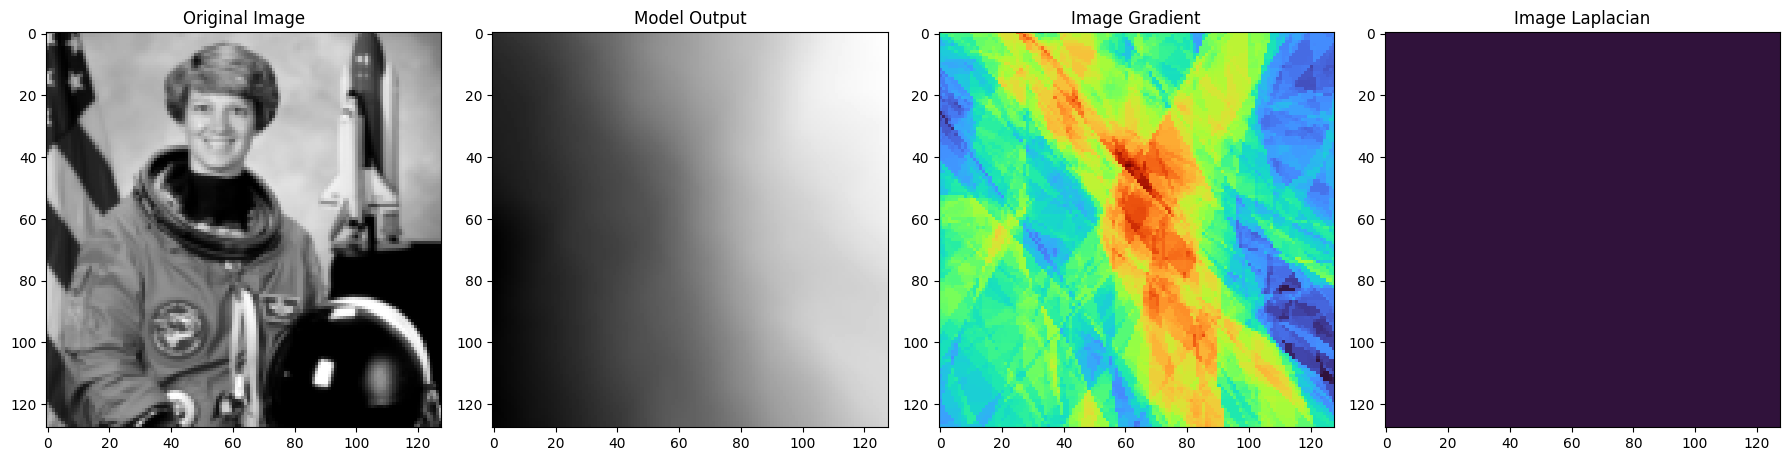

  5%|▍         | 97/2000 [00:01<00:30, 62.54it/s]

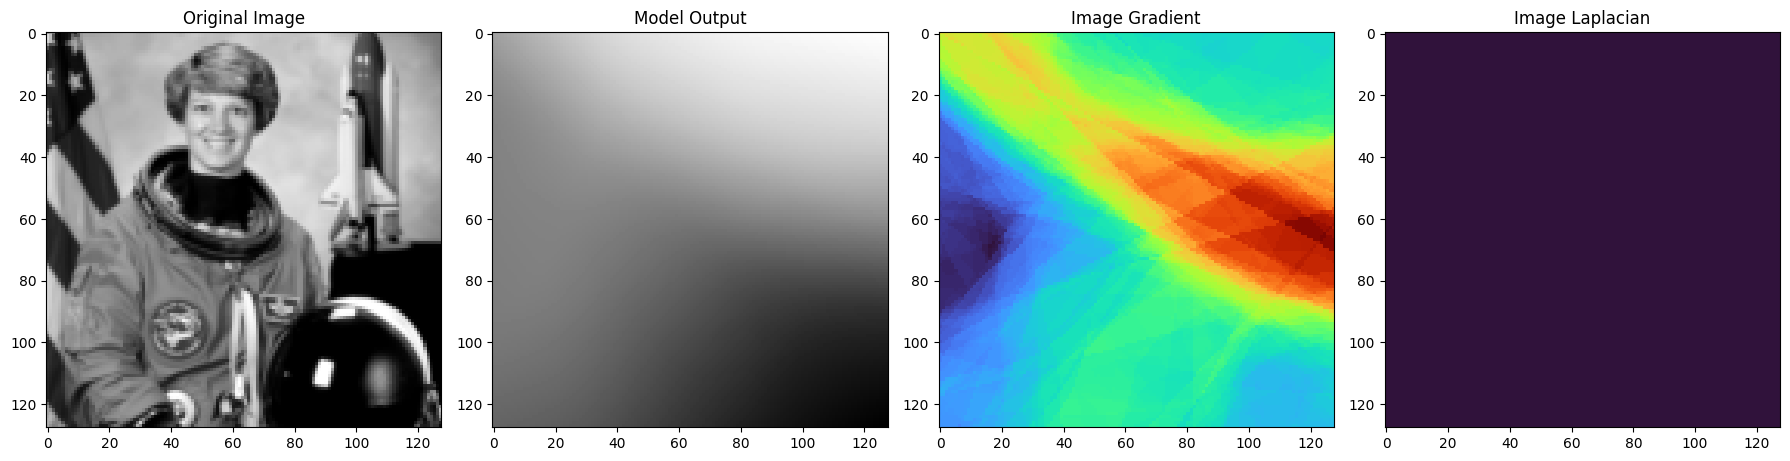

 10%|▉         | 197/2000 [00:04<00:32, 54.78it/s]

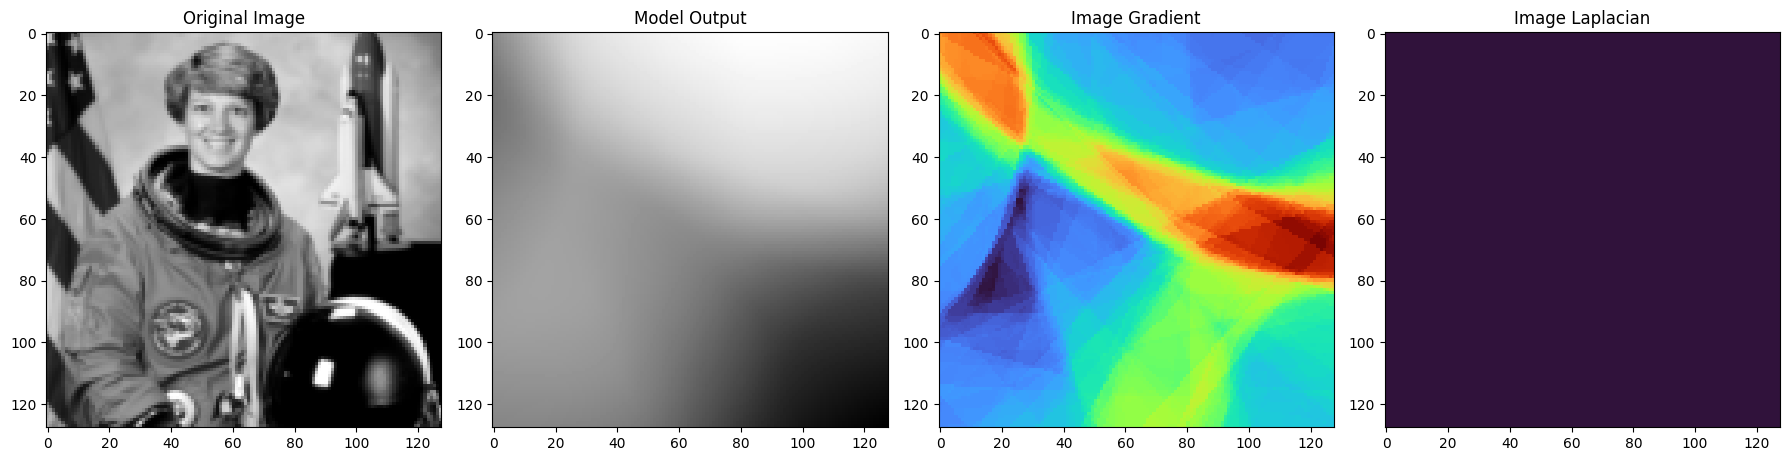

 15%|█▍        | 297/2000 [00:06<00:38, 44.39it/s]

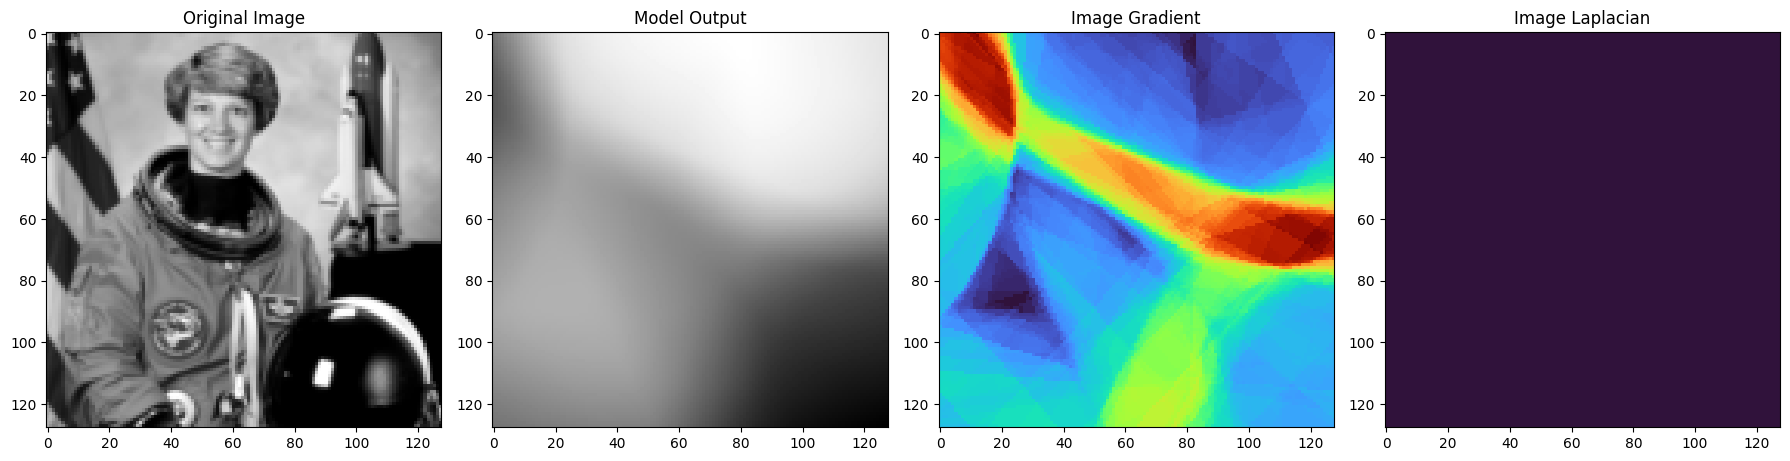

 20%|█▉        | 399/2000 [00:10<01:11, 22.51it/s]

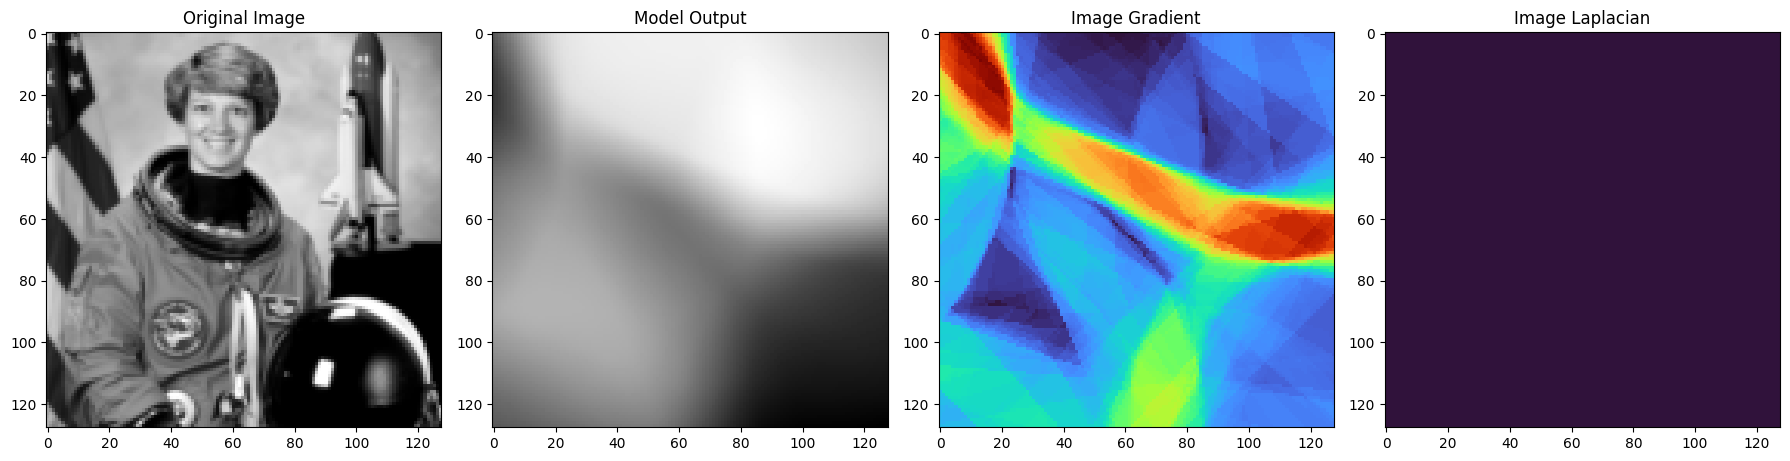

 25%|██▌       | 500/2000 [00:14<01:21, 18.51it/s]

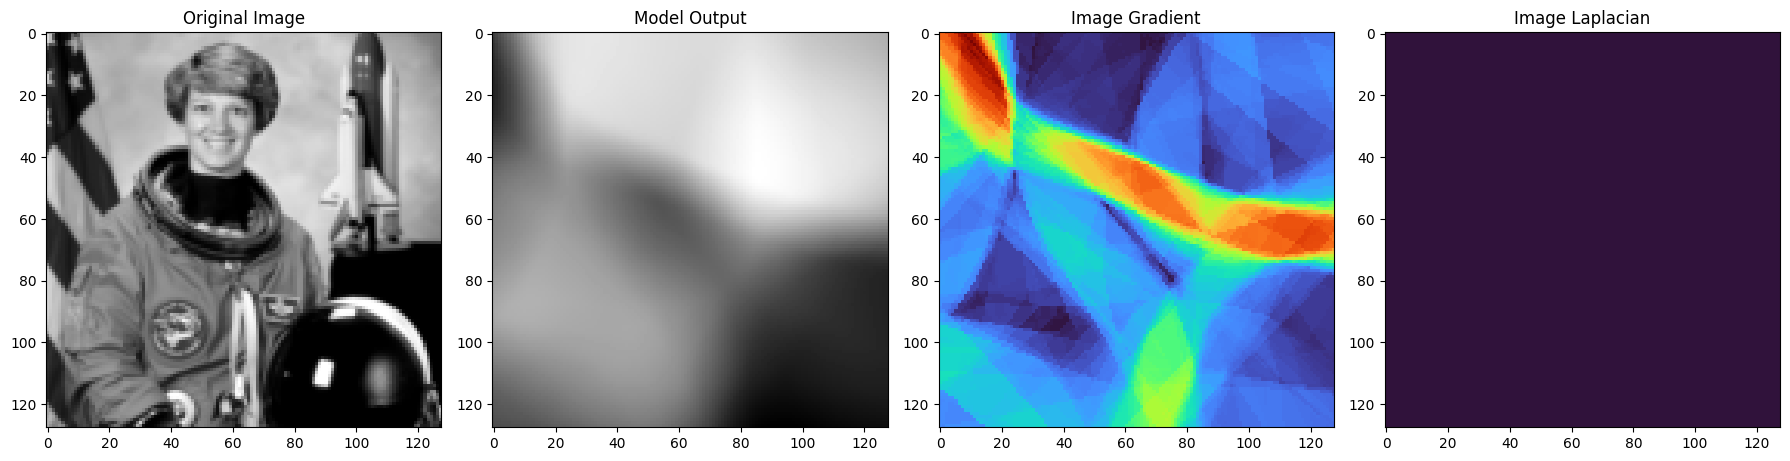

 30%|██▉       | 596/2000 [00:24<01:04, 21.73it/s]

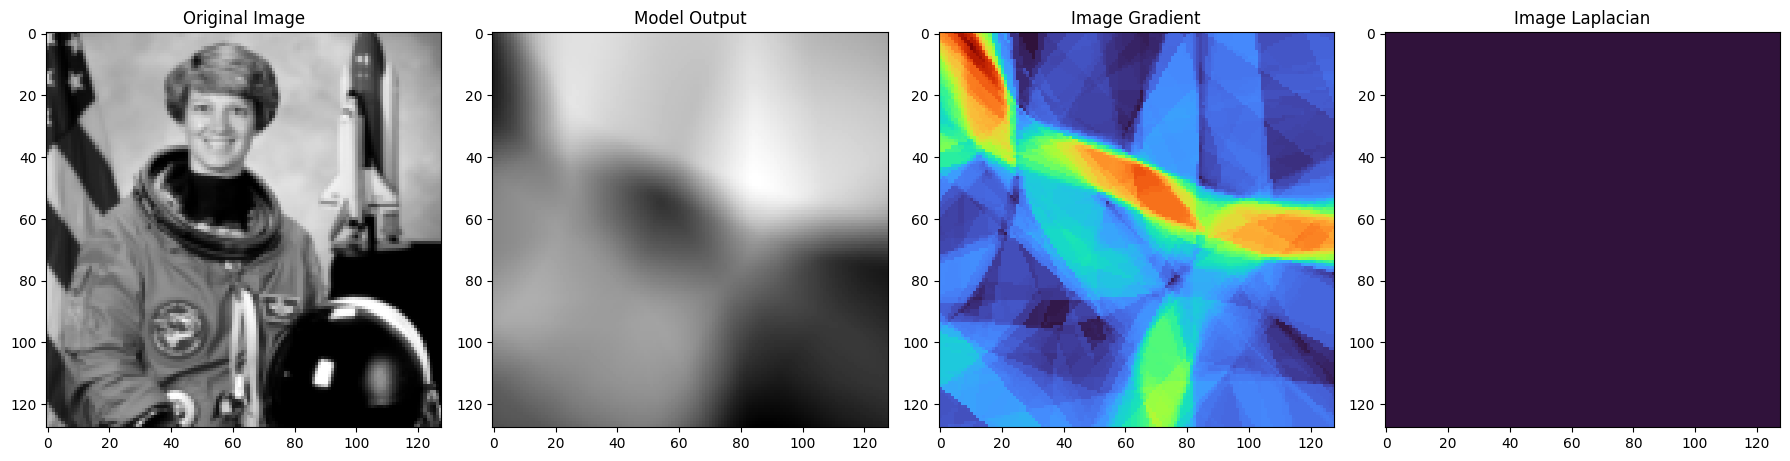

 35%|███▍      | 695/2000 [00:34<01:20, 16.26it/s]

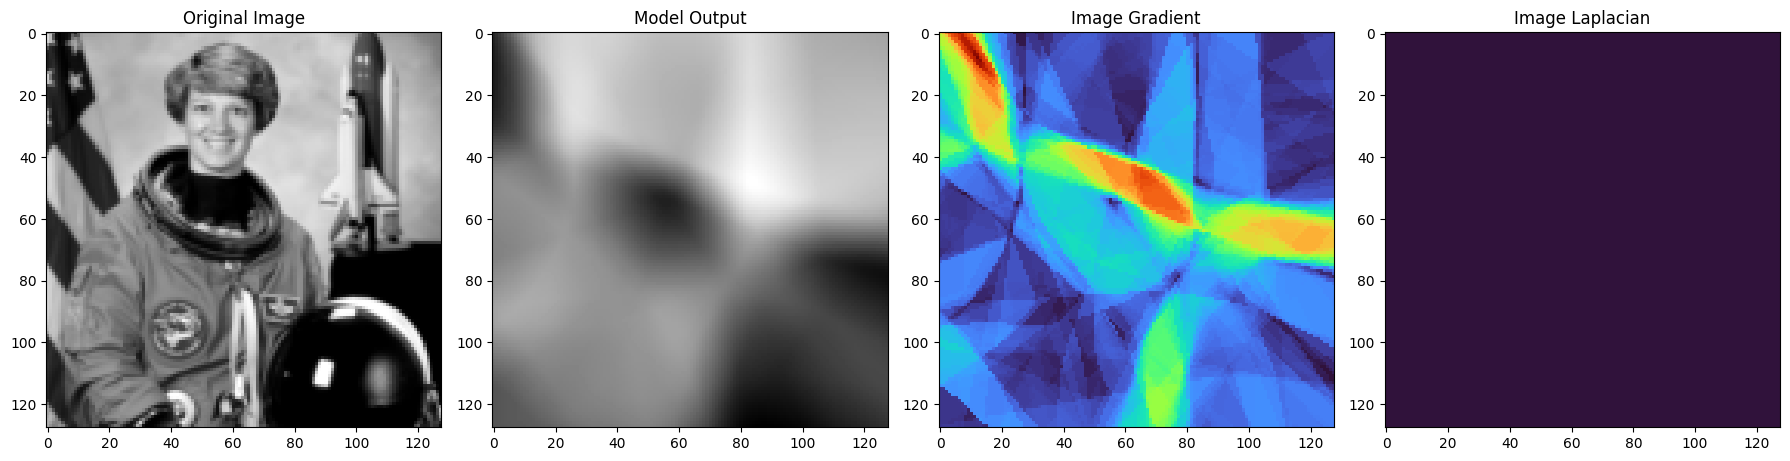

 40%|███▉      | 799/2000 [00:38<00:51, 23.34it/s]

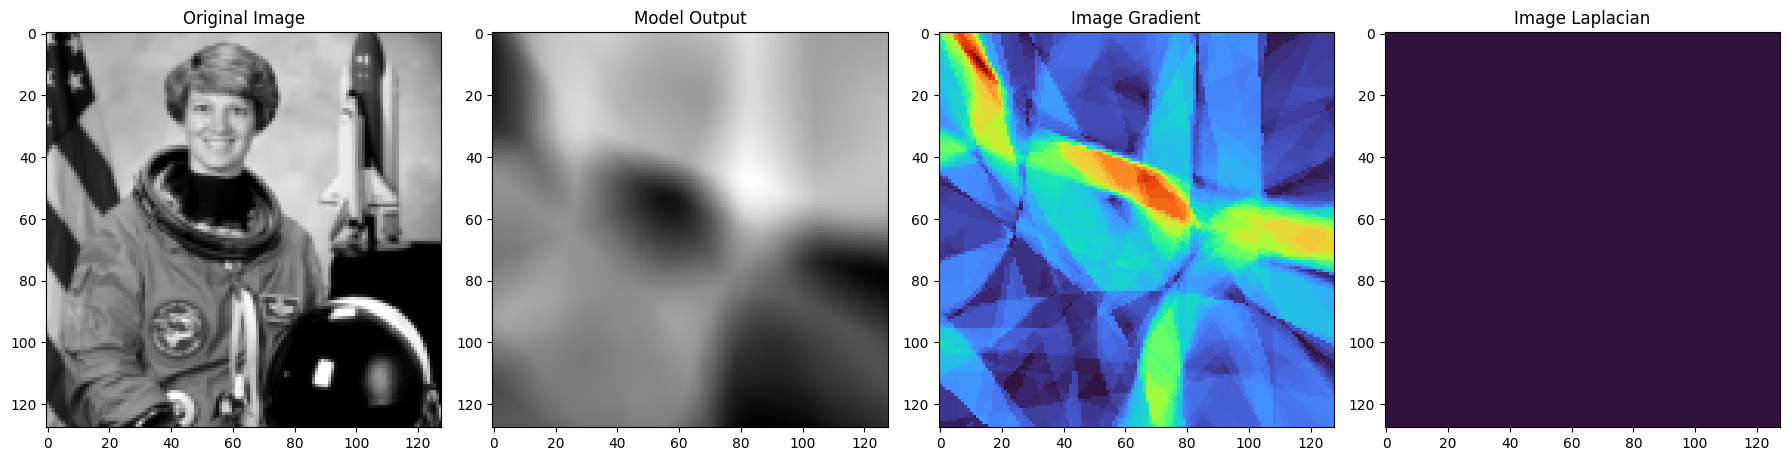

 45%|████▍     | 896/2000 [00:41<00:24, 44.52it/s]

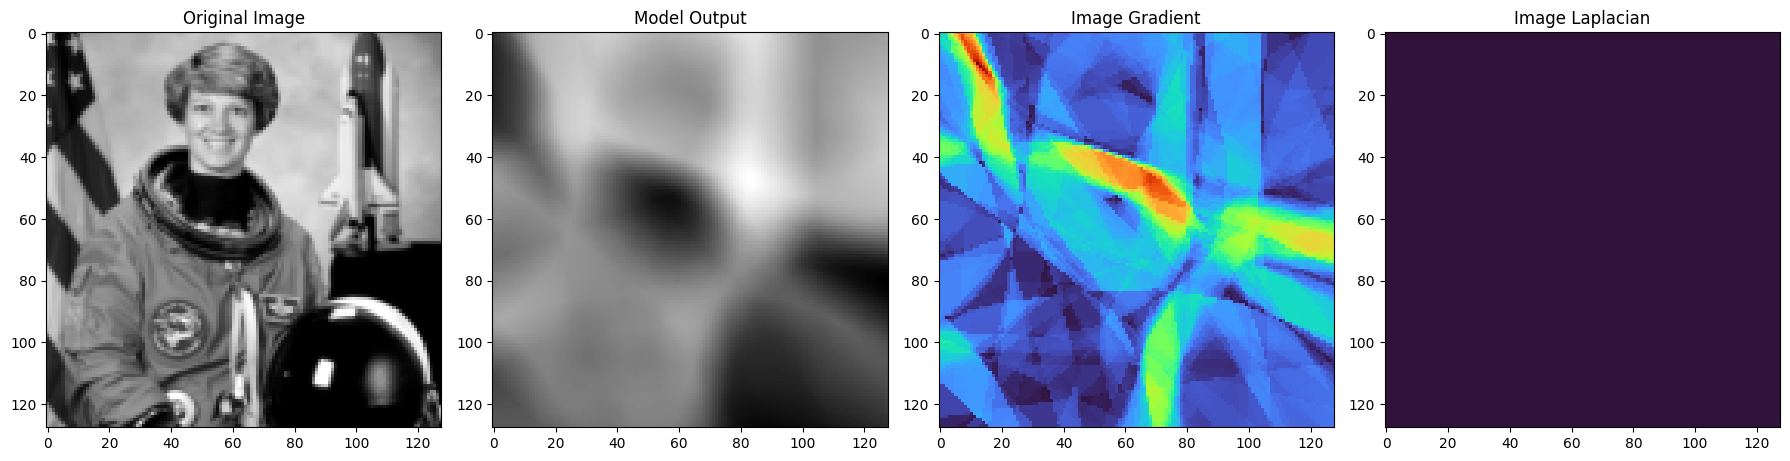

 50%|████▉     | 999/2000 [00:45<00:24, 40.38it/s]

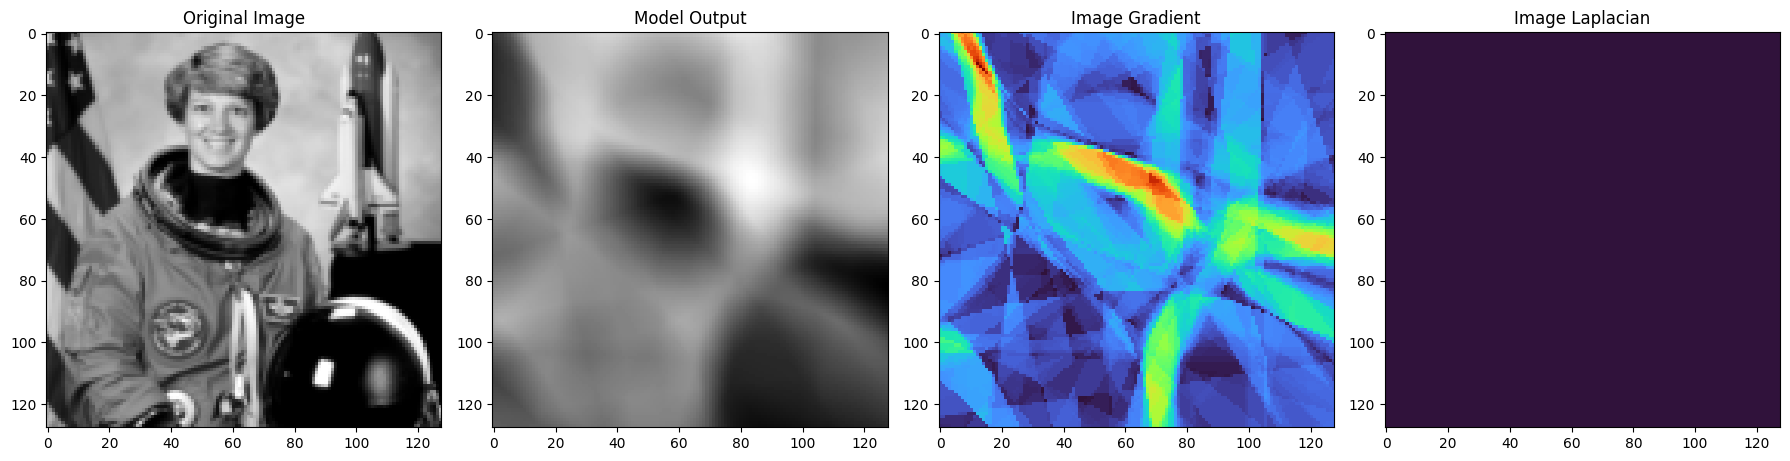

 55%|█████▍    | 1096/2000 [00:53<03:10,  4.75it/s]

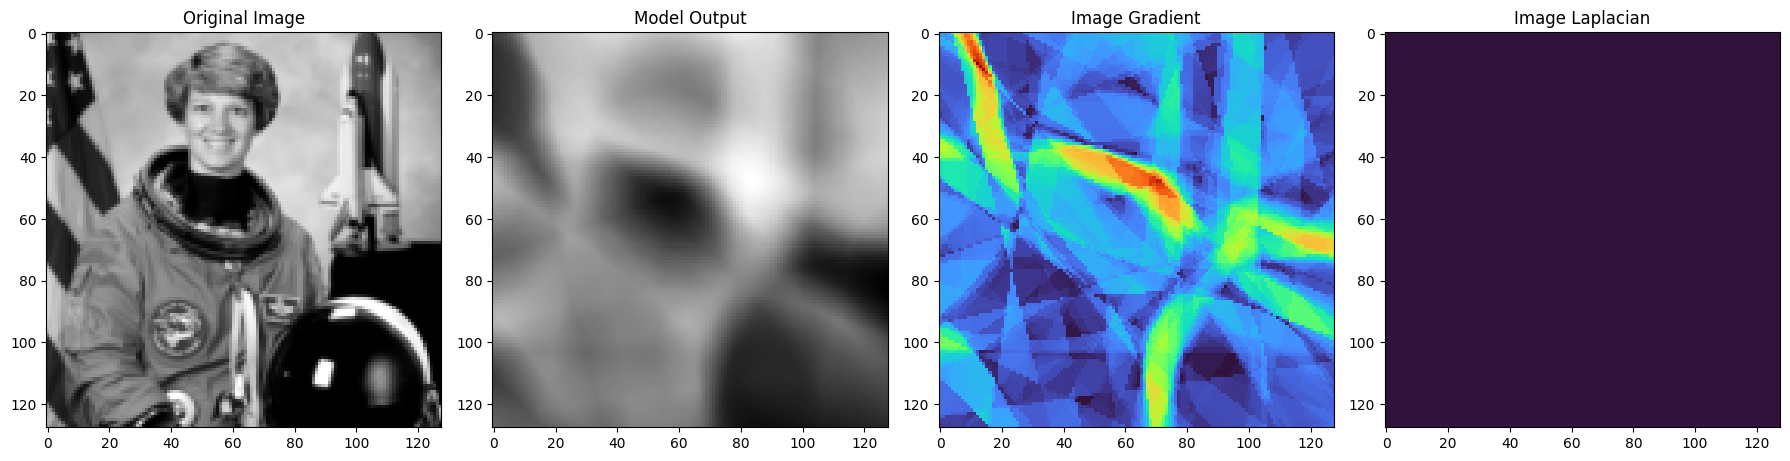

 60%|█████▉    | 1196/2000 [00:56<00:17, 45.12it/s]

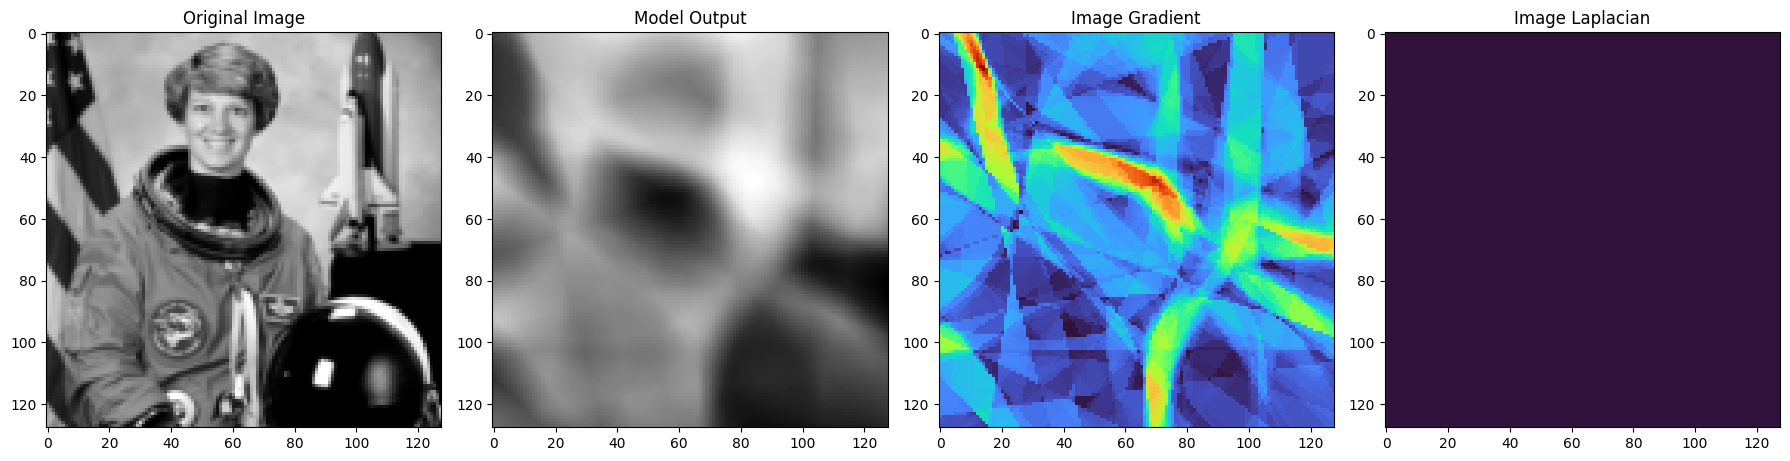

 65%|██████▍   | 1295/2000 [00:58<00:19, 36.26it/s]

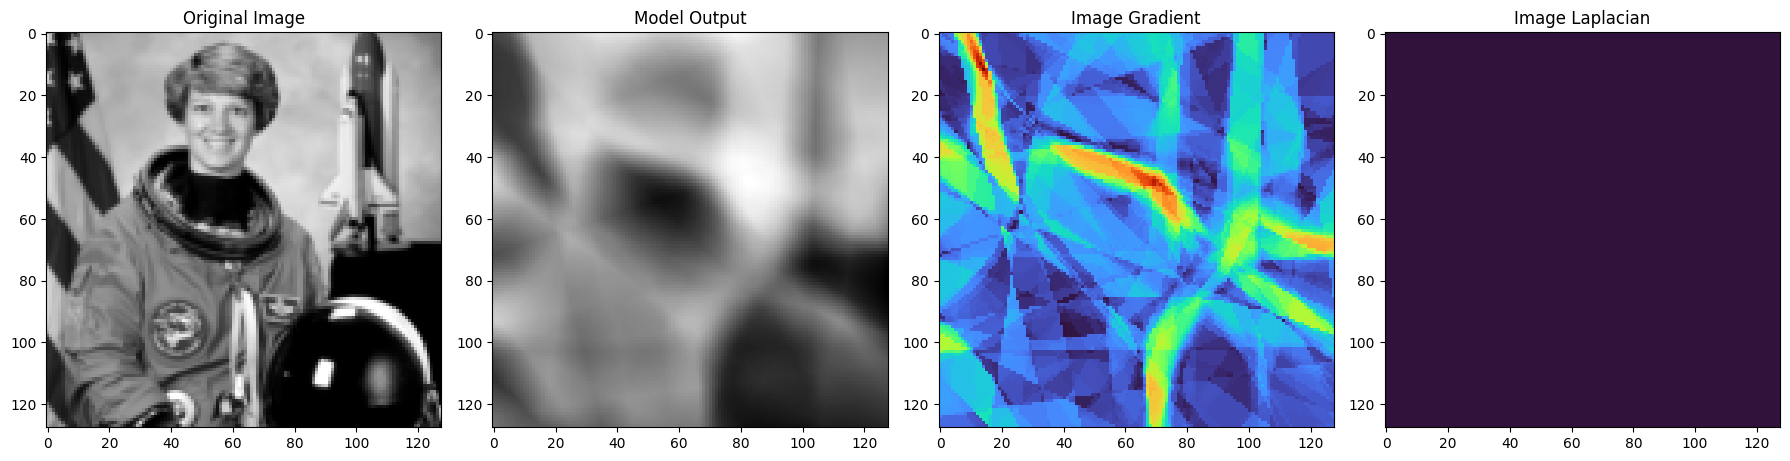

 70%|██████▉   | 1397/2000 [01:01<00:13, 45.16it/s]

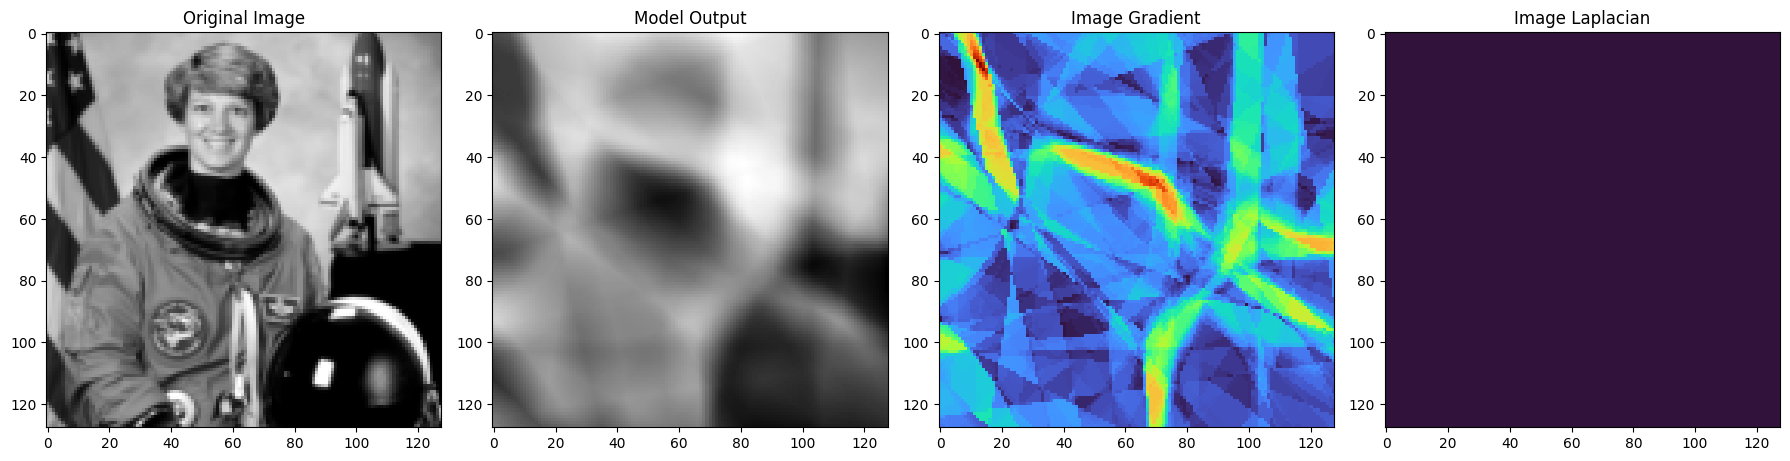

 75%|███████▍  | 1495/2000 [01:04<00:13, 37.85it/s]

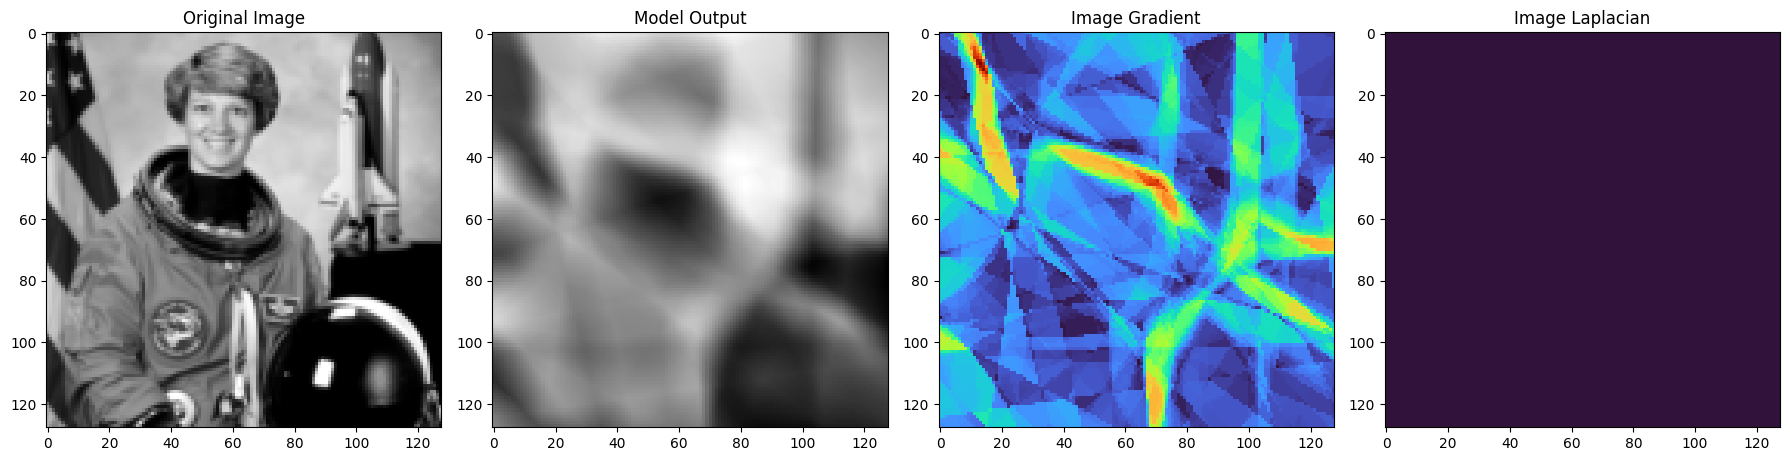

 80%|███████▉  | 1597/2000 [01:06<00:07, 52.61it/s]

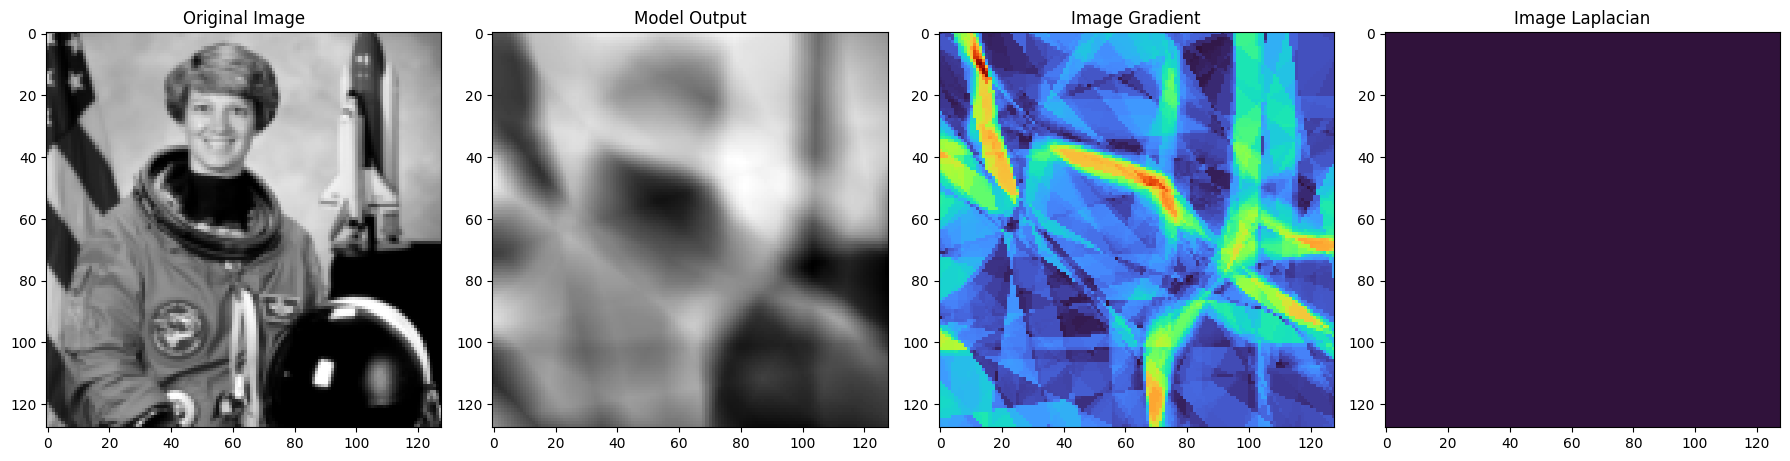

 85%|████████▍ | 1695/2000 [01:10<00:08, 35.04it/s]

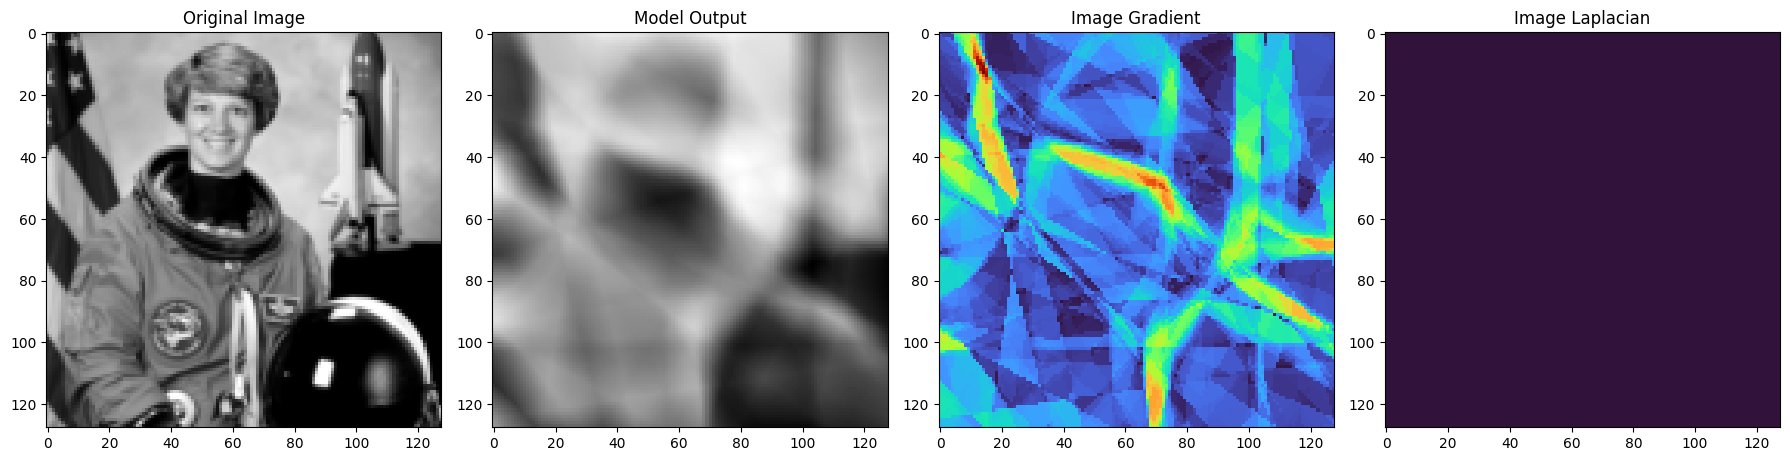

 90%|████████▉ | 1799/2000 [01:12<00:03, 52.14it/s]

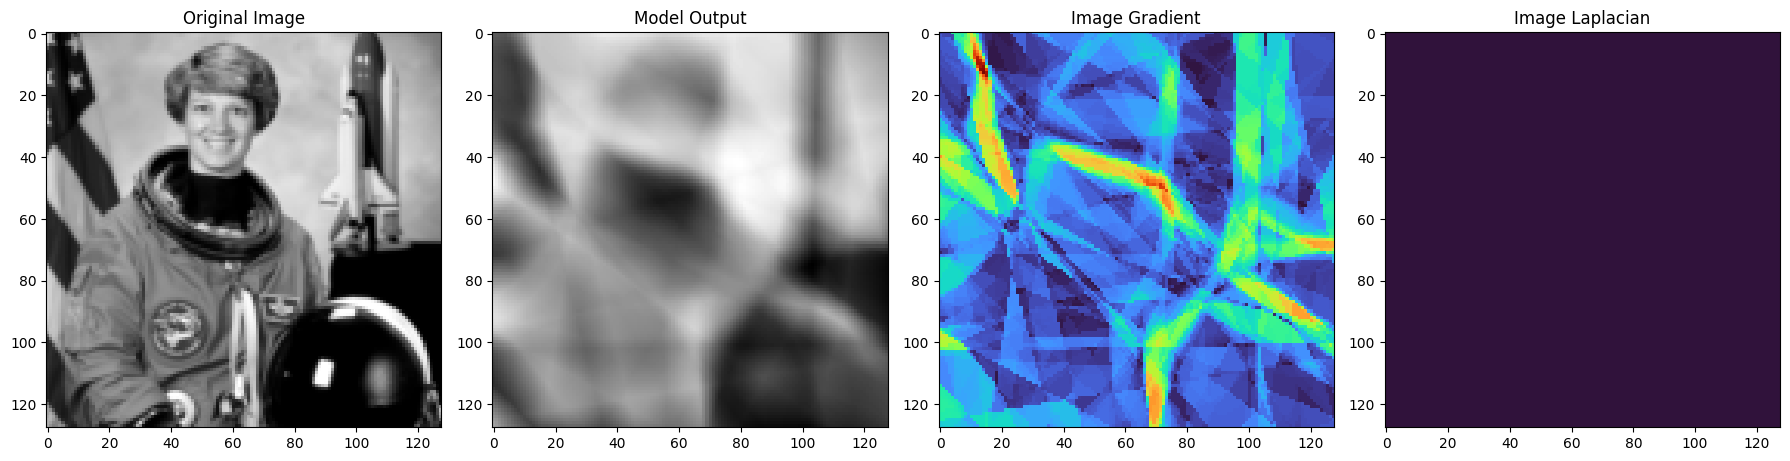

 95%|█████████▌| 1900/2000 [01:15<00:02, 36.40it/s]

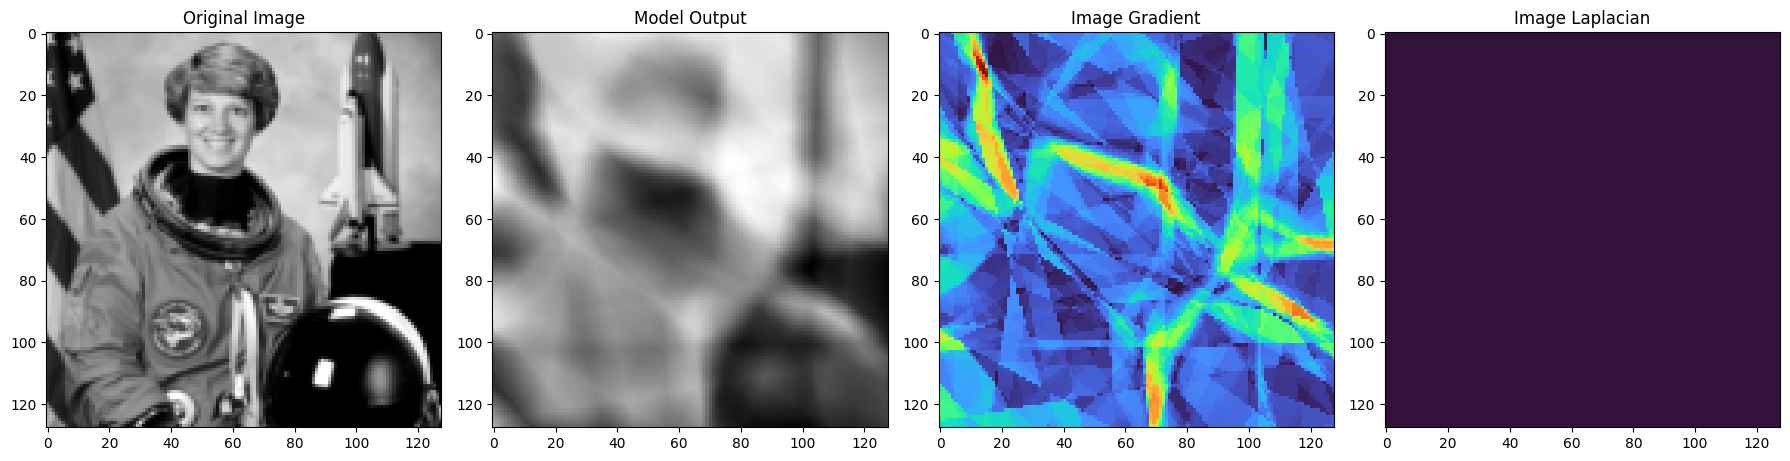

100%|██████████| 2000/2000 [01:18<00:00, 25.48it/s]


In [7]:
dataset = ImageDataset(height=128)

mlp_loss, mlp_psnr = train(
    model="MLP",
    dataset=dataset,
    lr=1e-4,
    total_steps=2000,
    steps_til_summary=100,
    device=device,
    **dict(
        in_features=2,
        out_features=1,
        hidden_features=128,
        hidden_layers=3,
        activation="ReLU",
    ),
)

Now fit the SIREN.

  0%|          | 0/500 [00:00<?, ?it/s]

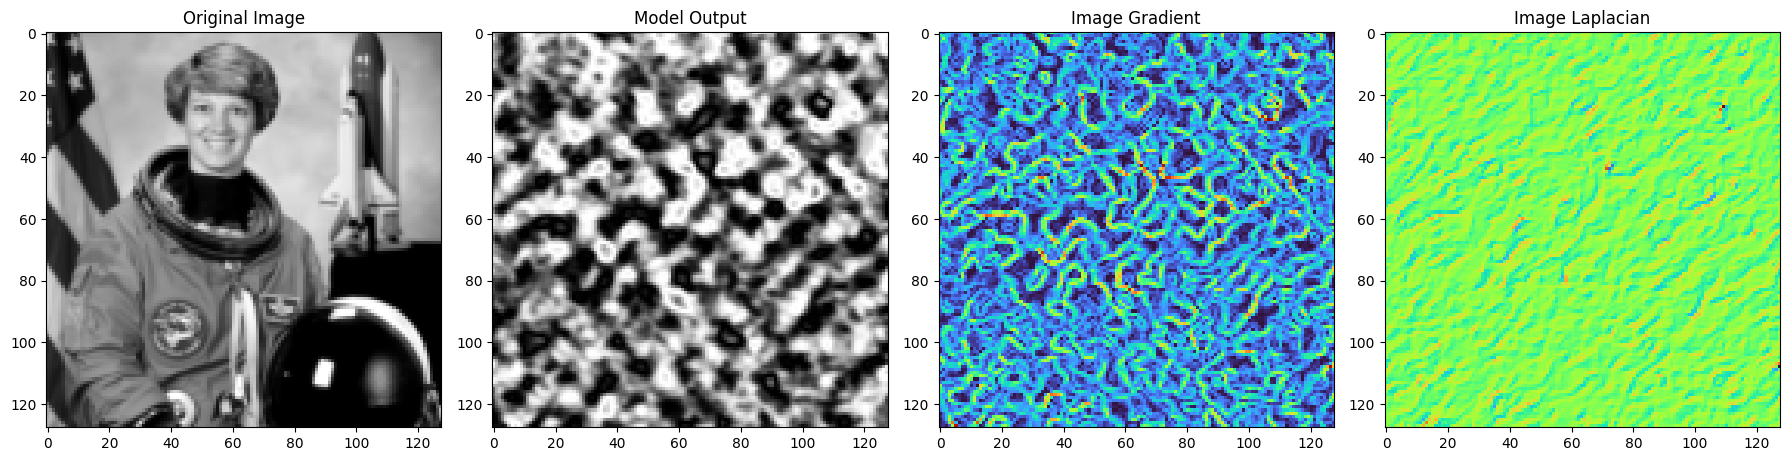

  5%|▌         | 25/500 [00:00<00:11, 41.86it/s]

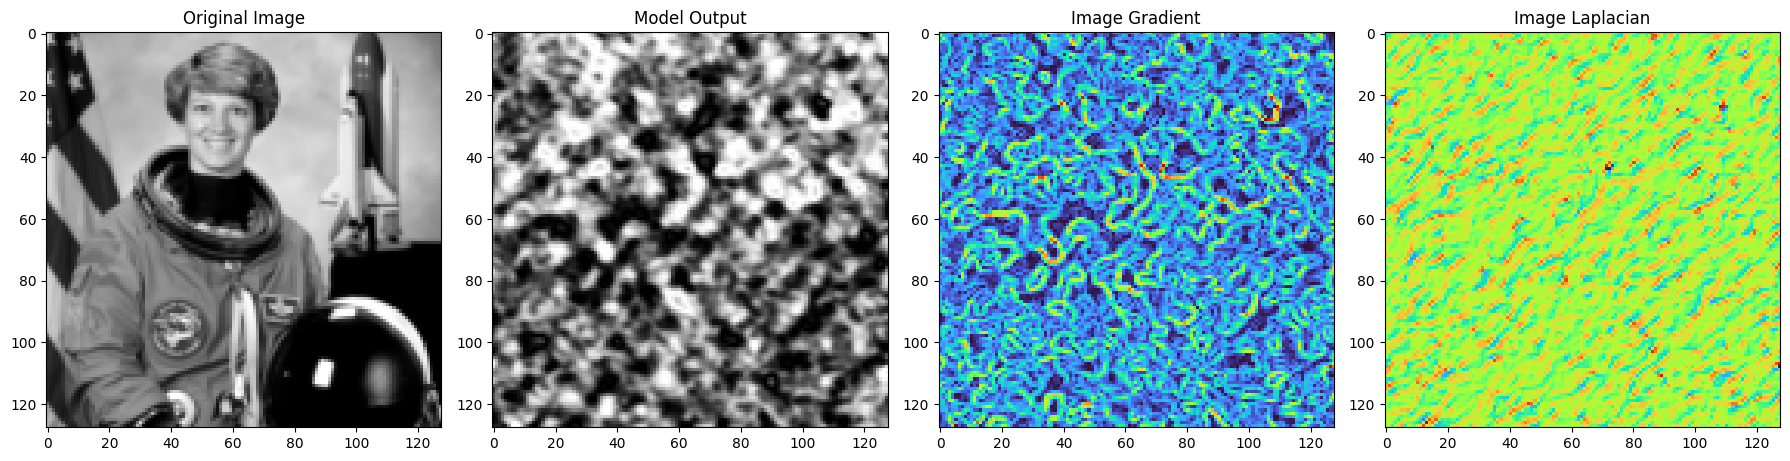

 10%|▉         | 49/500 [00:01<00:10, 41.73it/s]

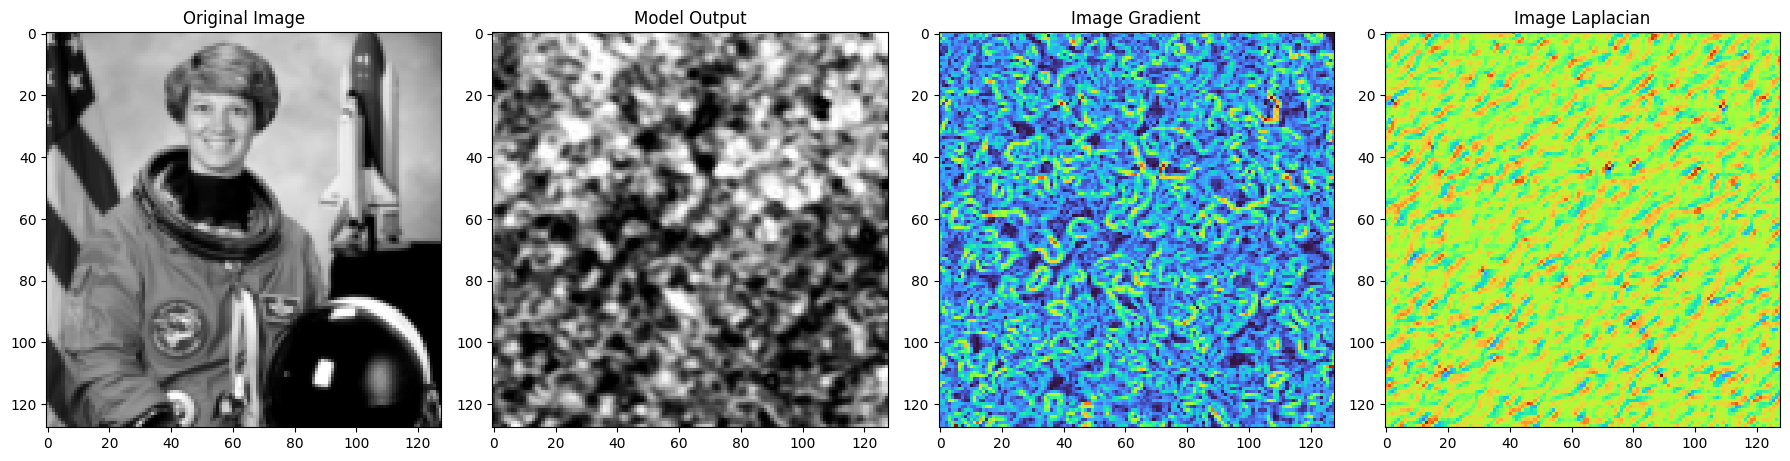

 15%|█▍        | 73/500 [00:02<00:10, 41.74it/s]

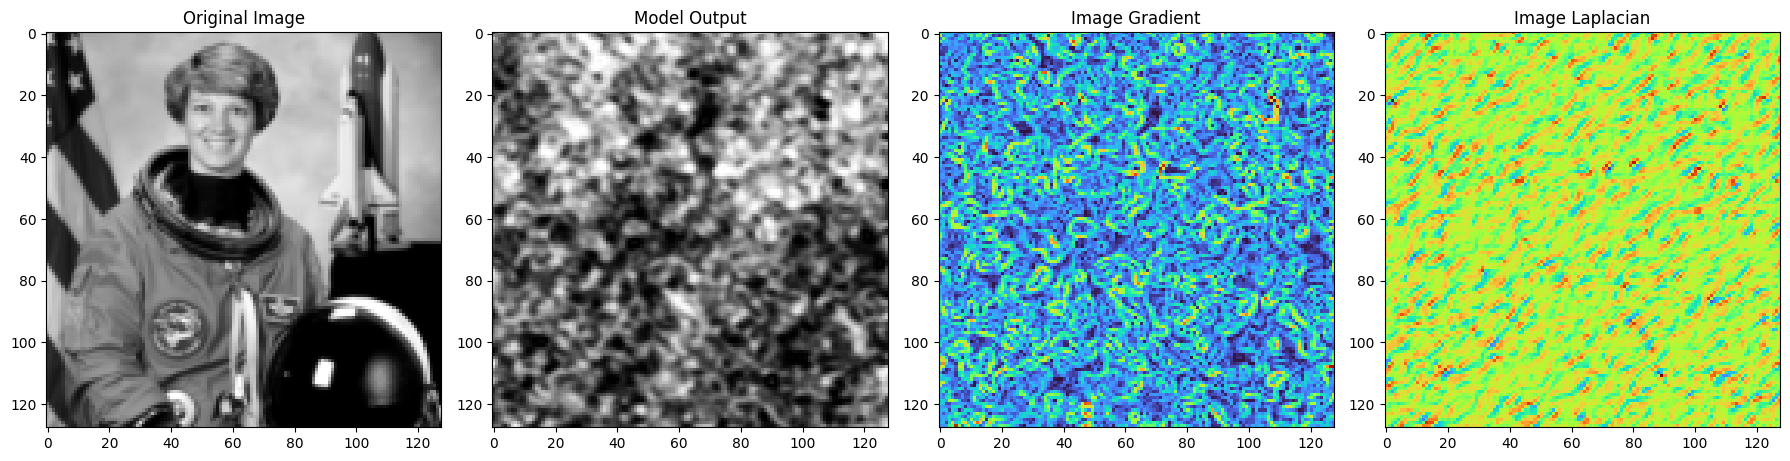

 19%|█▉        | 95/500 [00:02<00:10, 39.76it/s]

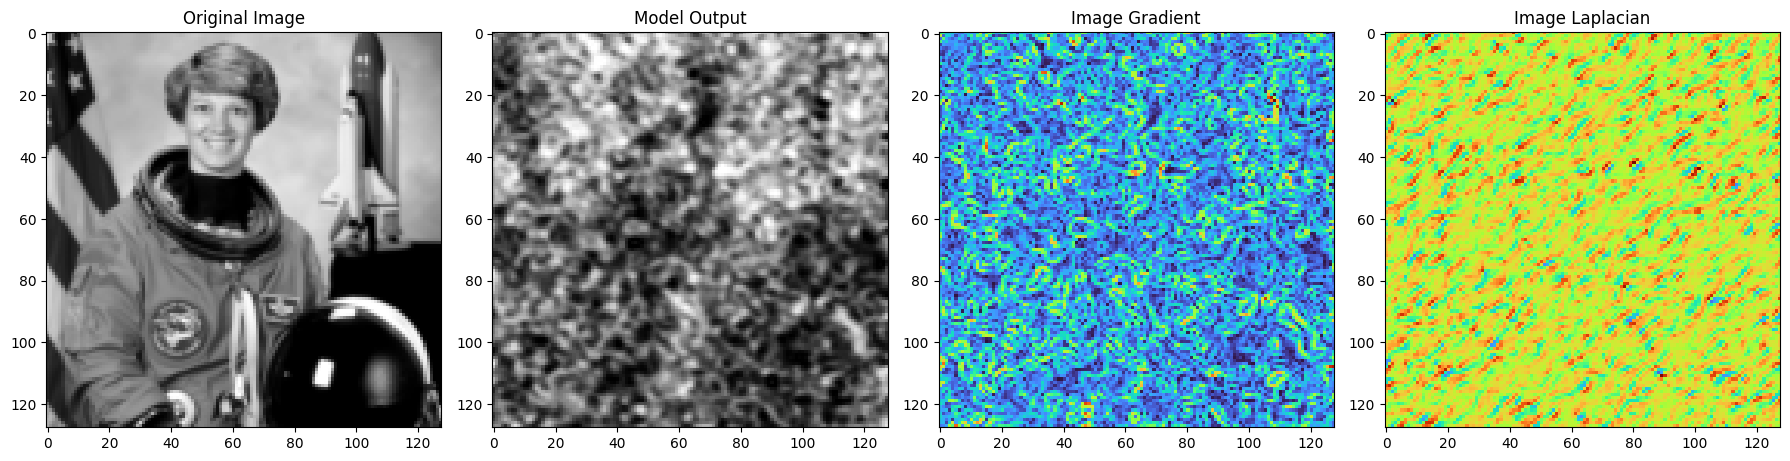

 25%|██▌       | 125/500 [00:03<00:08, 43.49it/s]

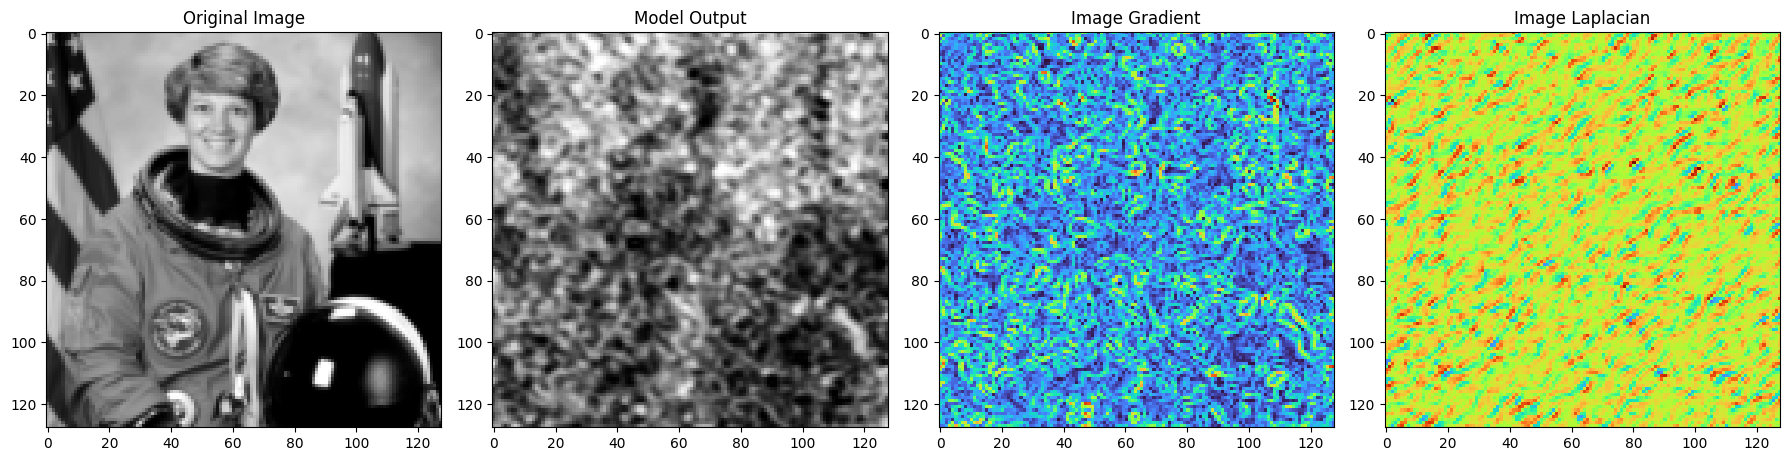

 30%|██▉       | 148/500 [00:04<00:08, 41.57it/s]

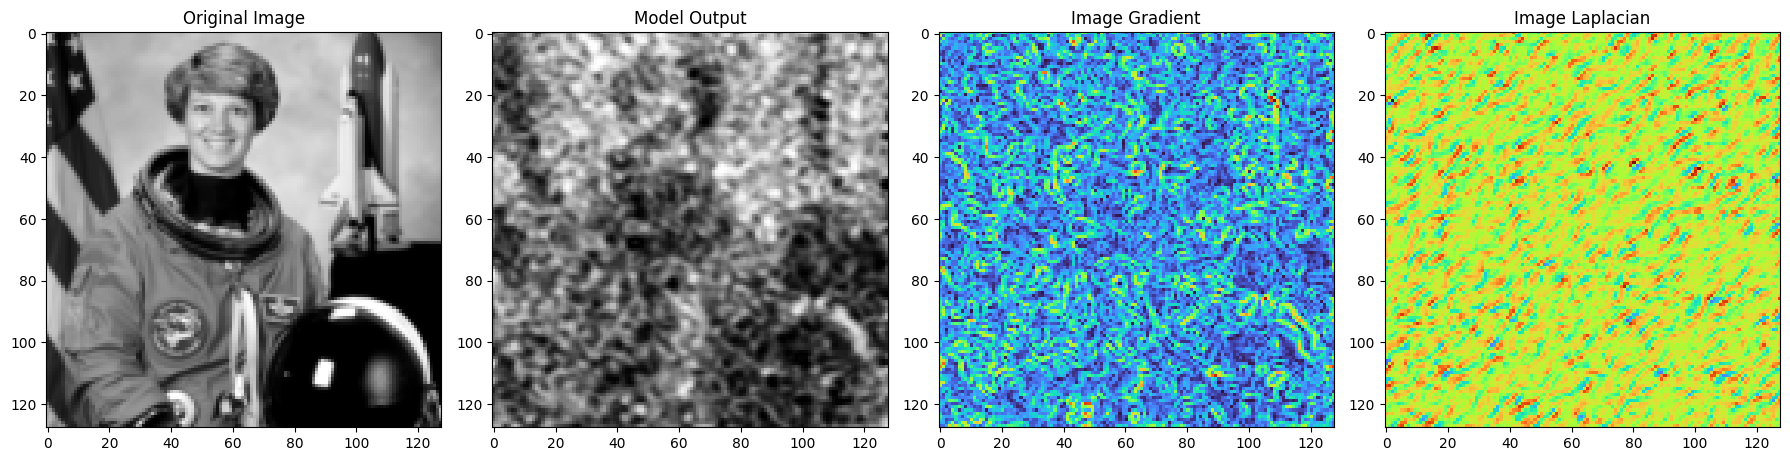

 34%|███▍      | 171/500 [00:05<00:08, 40.51it/s]

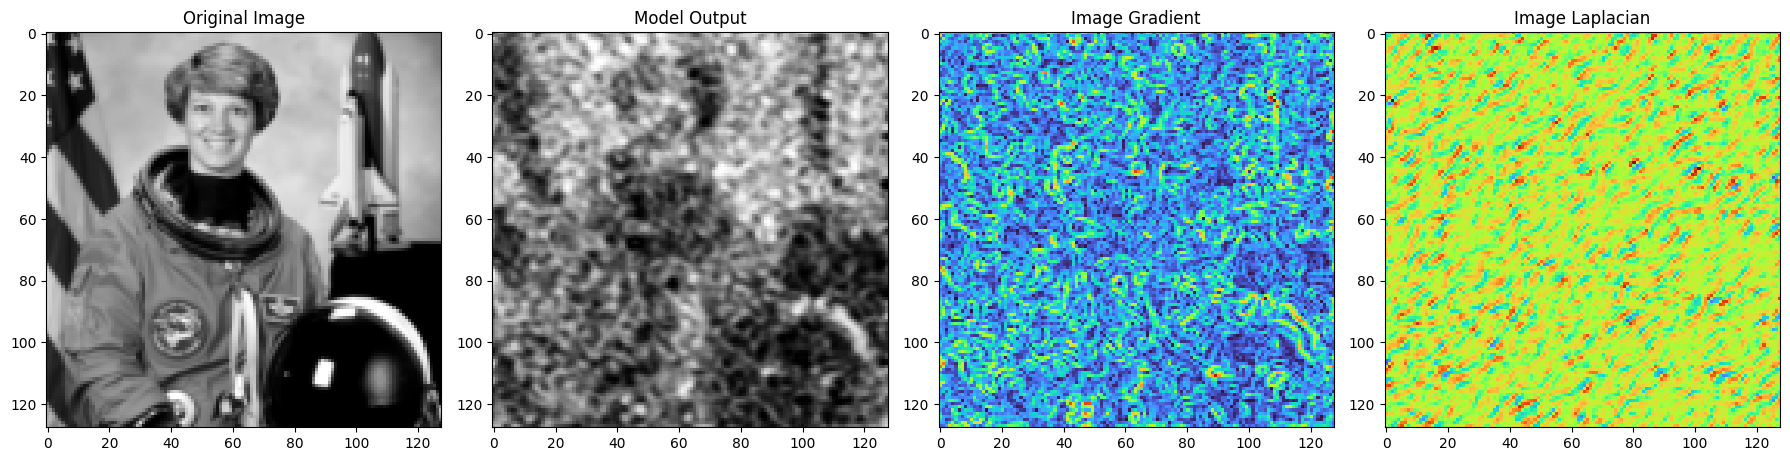

 40%|████      | 200/500 [00:05<00:06, 44.15it/s]

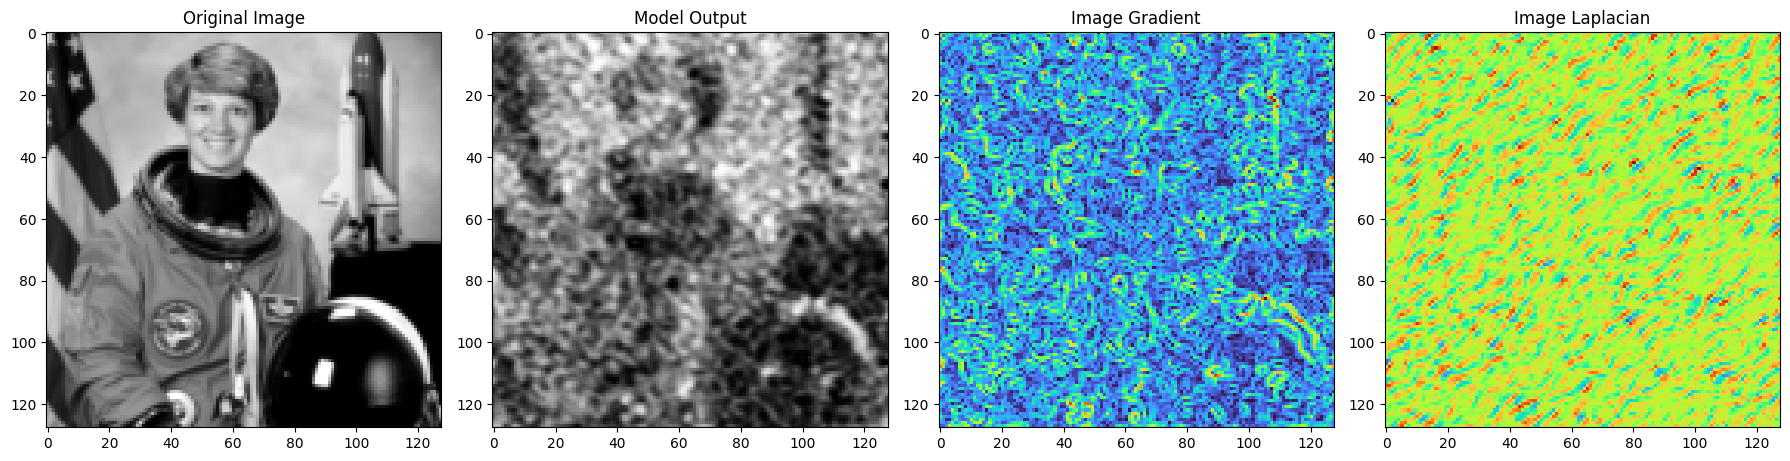

 44%|████▍     | 222/500 [00:06<00:07, 38.53it/s]

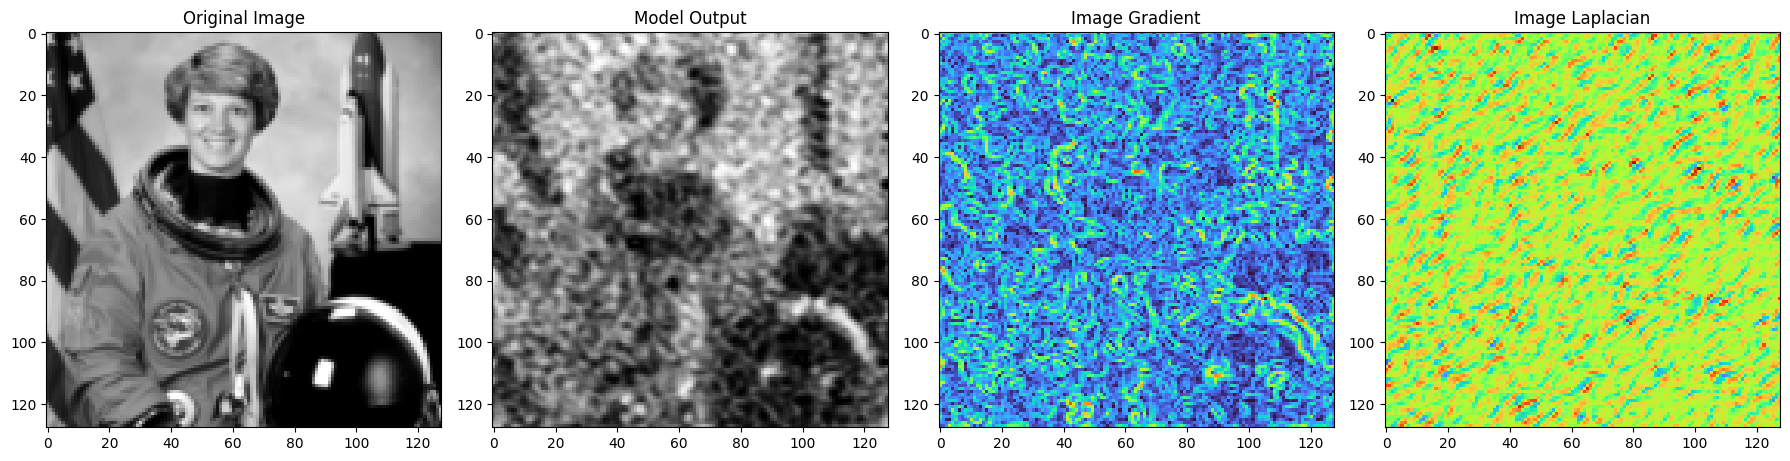

 50%|█████     | 250/500 [00:07<00:05, 42.00it/s]

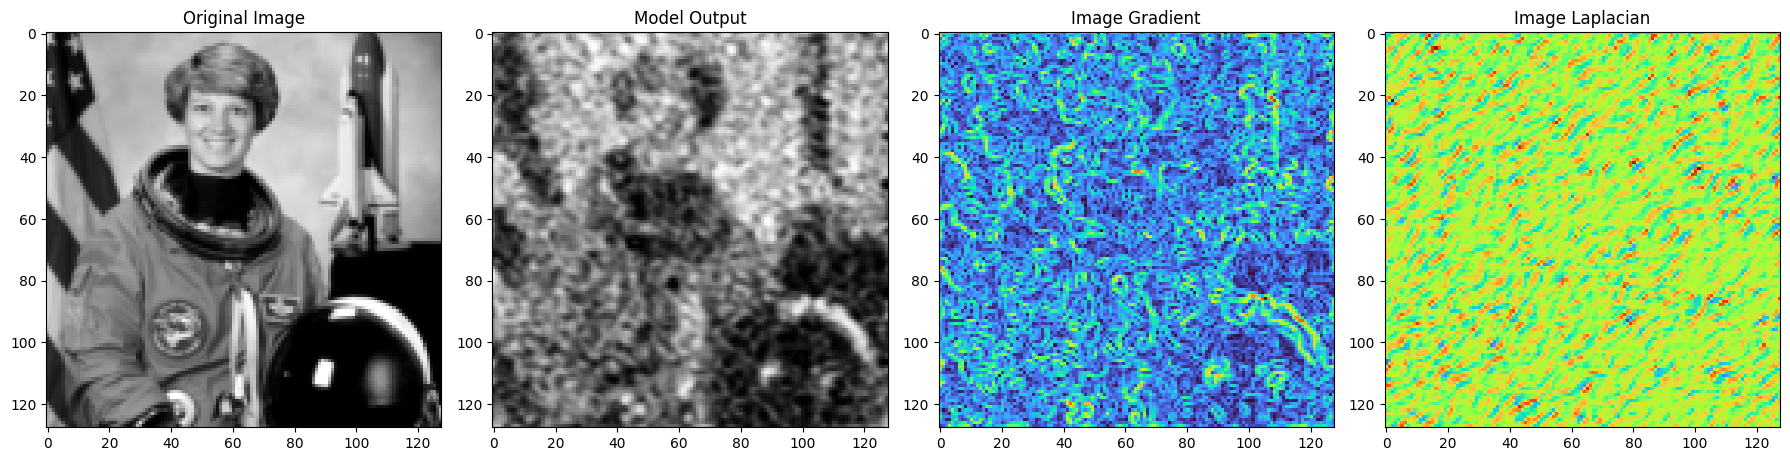

 54%|█████▍    | 272/500 [00:08<00:05, 39.81it/s]

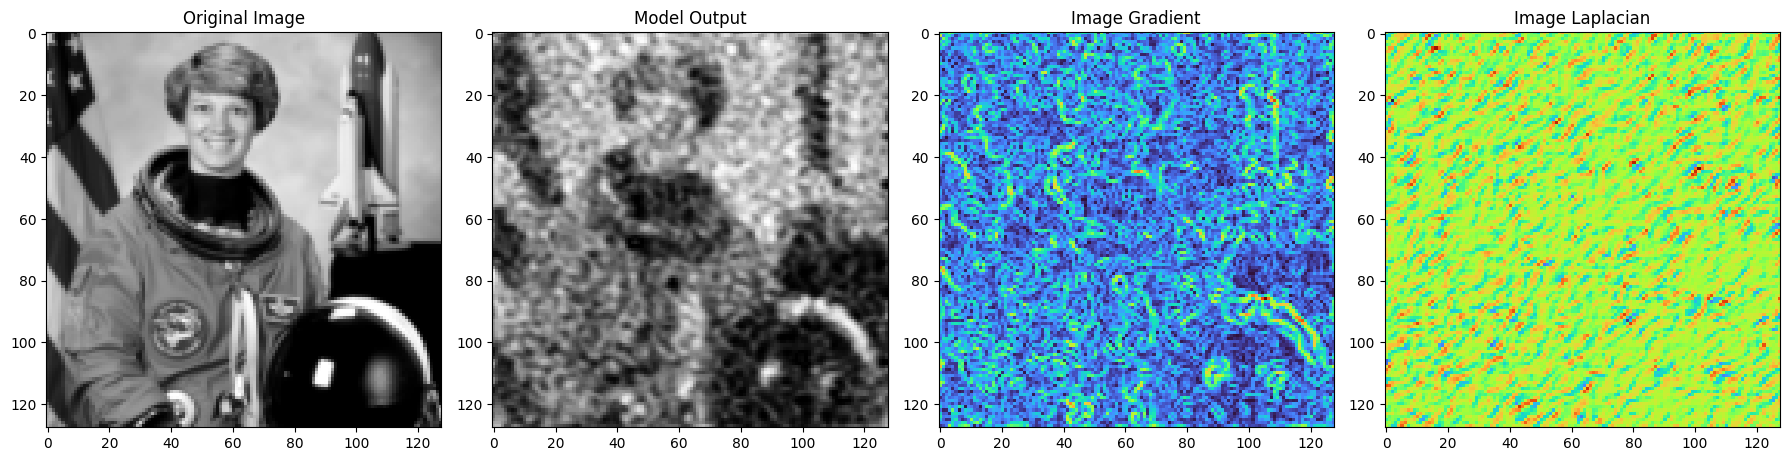

 60%|█████▉    | 298/500 [00:08<00:05, 39.25it/s]

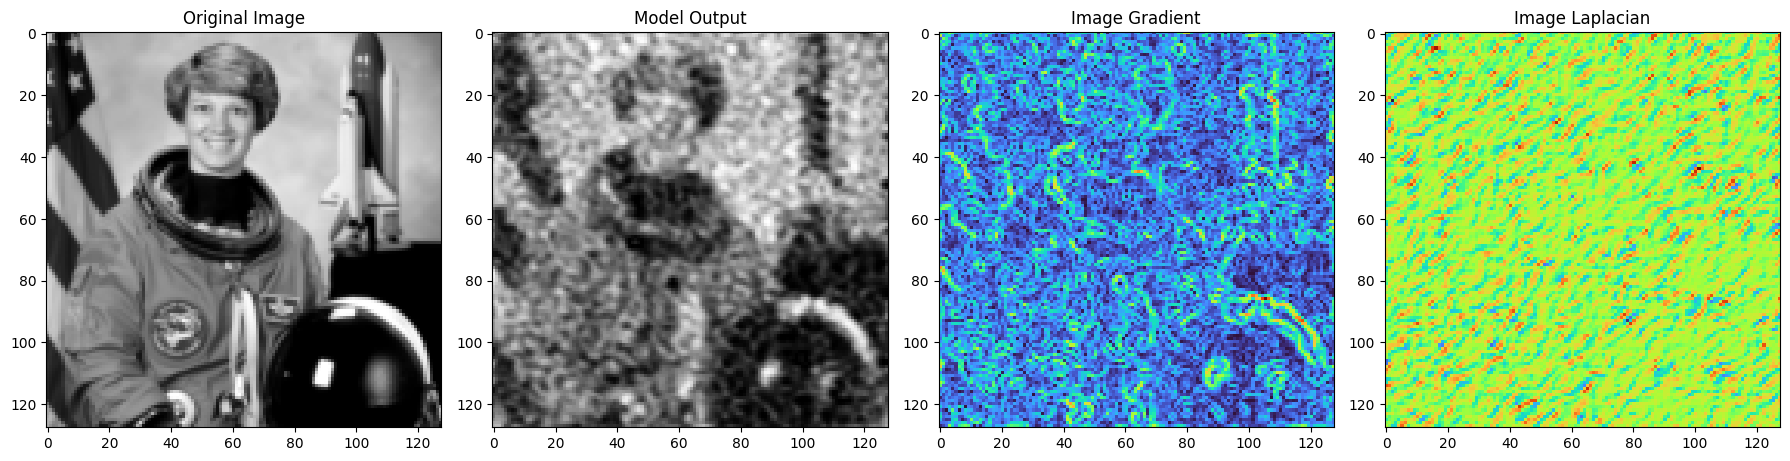

 65%|██████▍   | 324/500 [00:09<00:04, 39.09it/s]

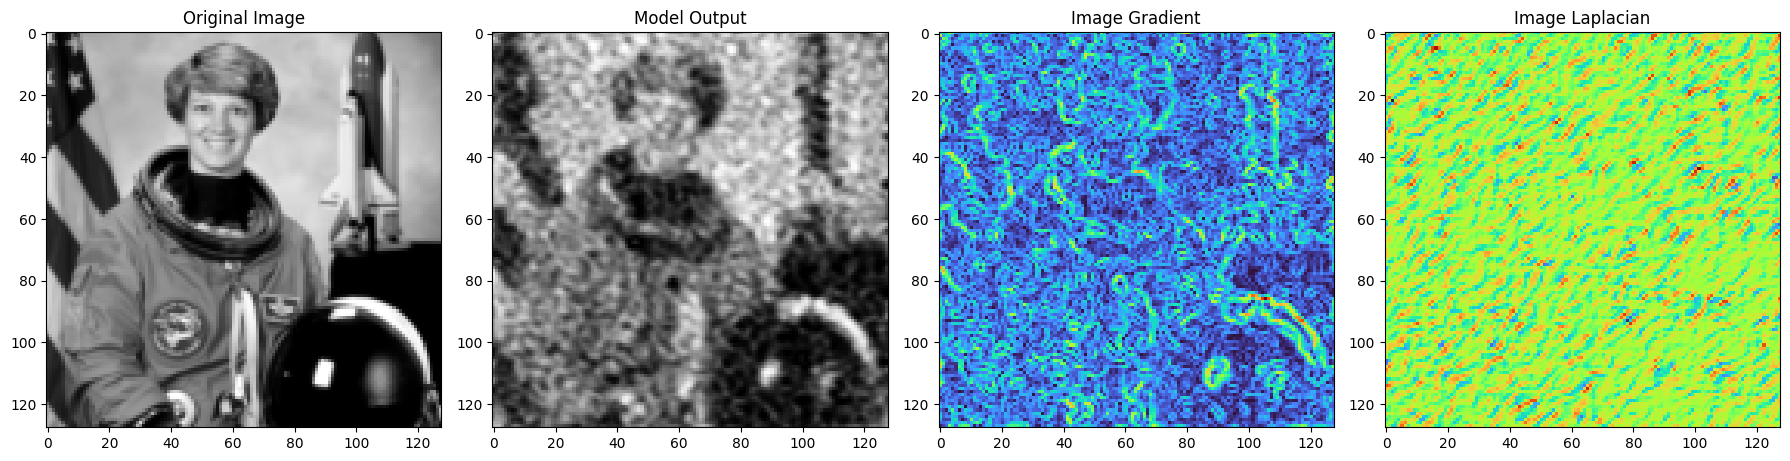

 70%|███████   | 350/500 [00:10<00:04, 35.74it/s]

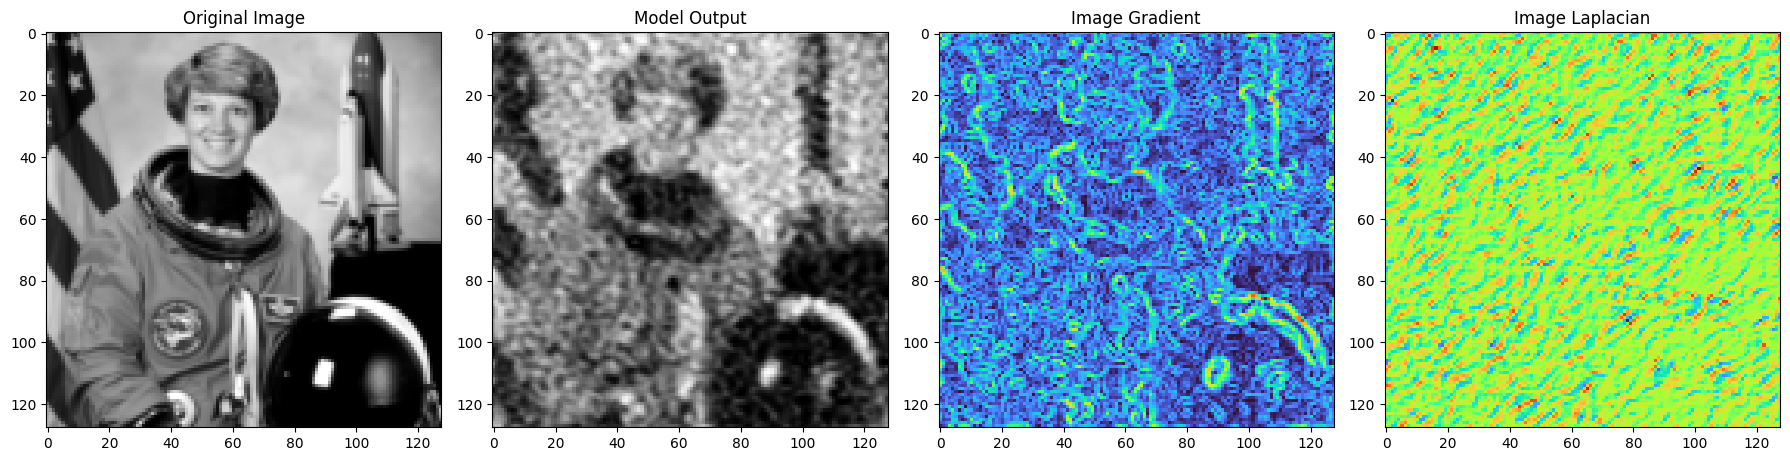

 75%|███████▌  | 375/500 [00:11<00:03, 37.23it/s]

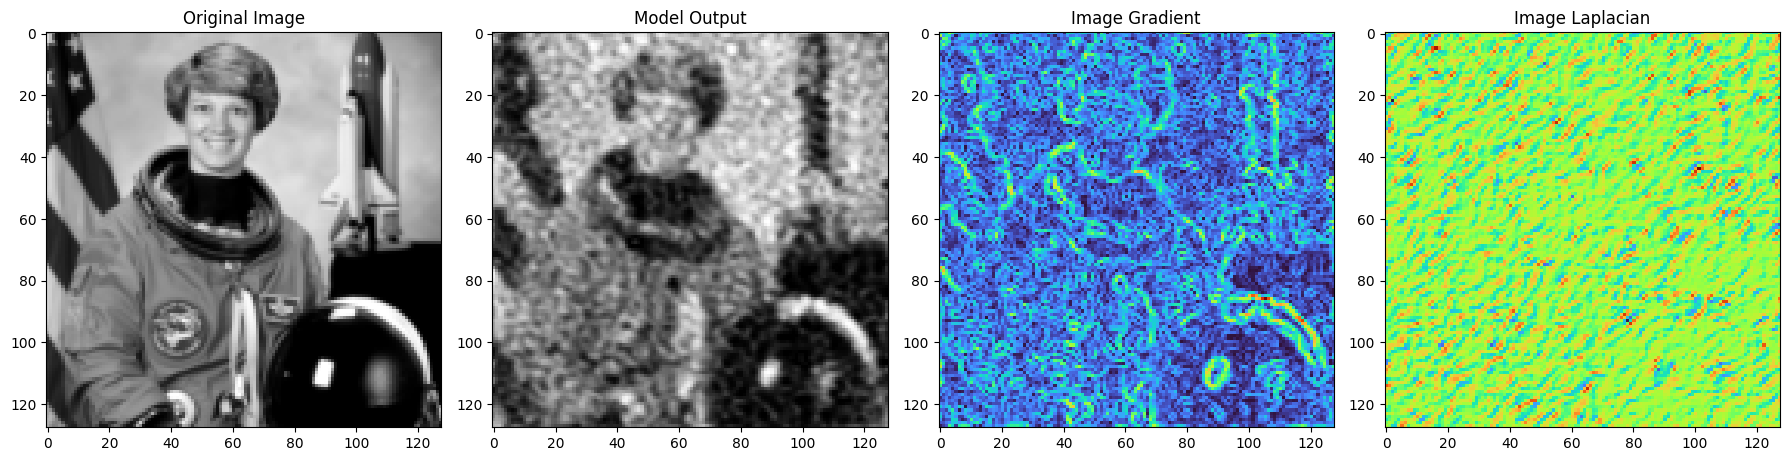

 80%|███████▉  | 399/500 [00:12<00:02, 37.97it/s]

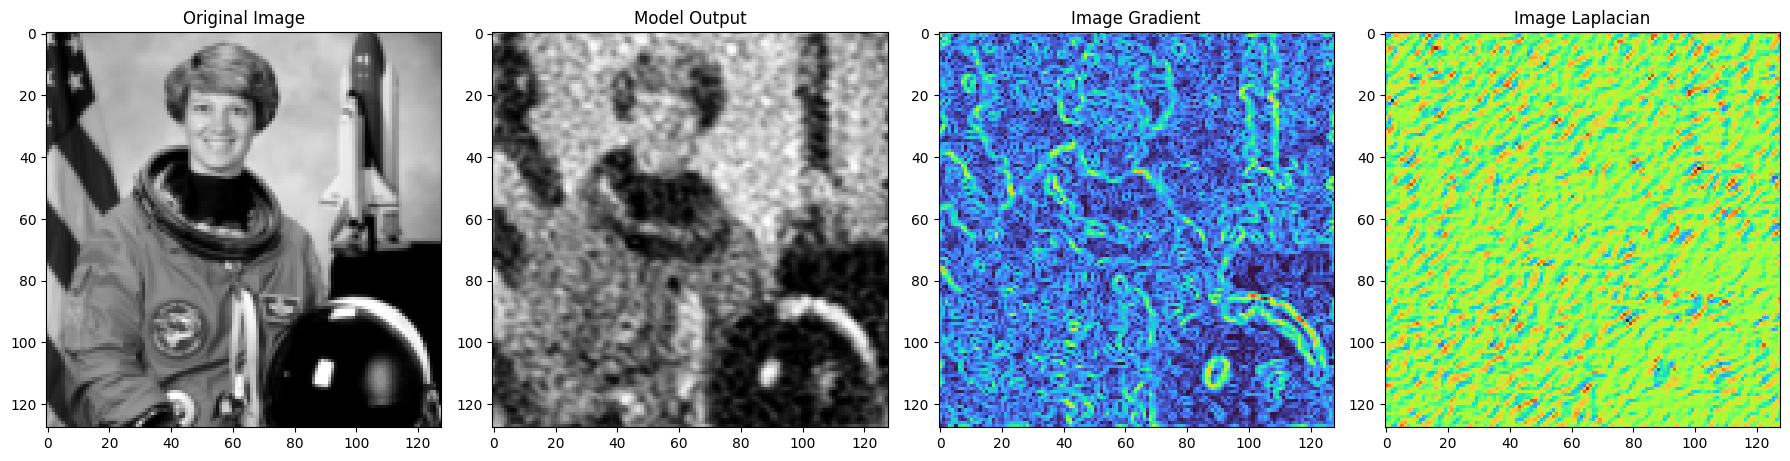

 85%|████████▍ | 424/500 [00:13<00:02, 37.22it/s]

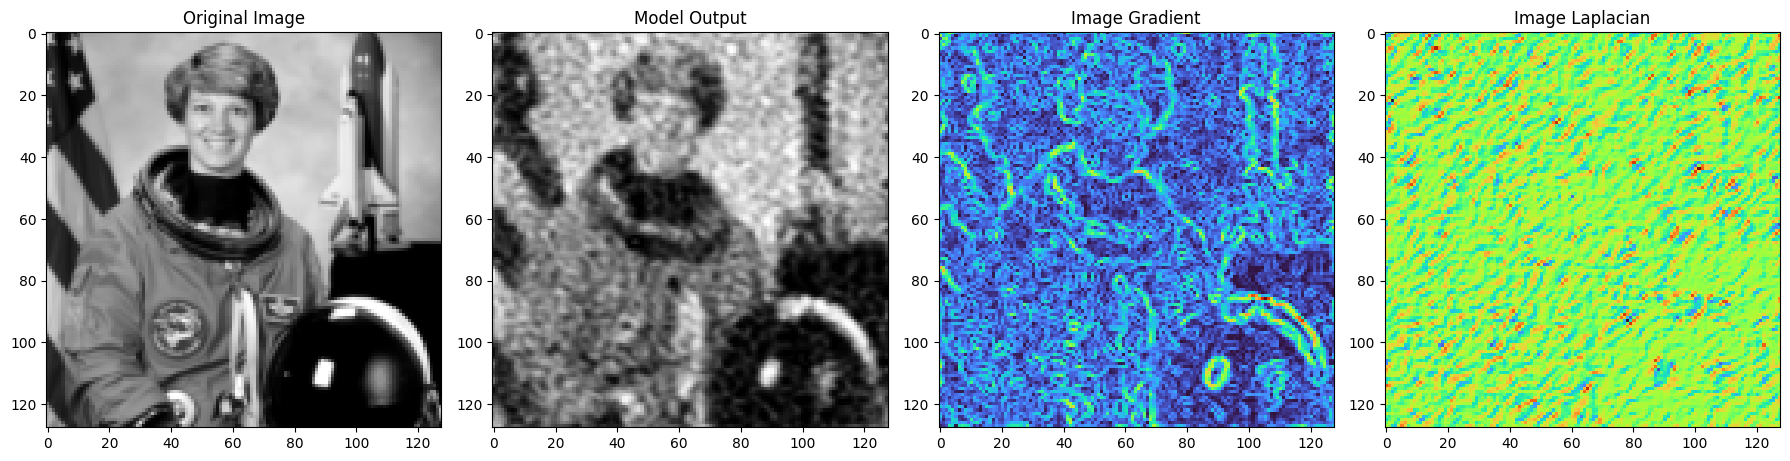

 90%|█████████ | 450/500 [00:14<00:01, 38.73it/s]

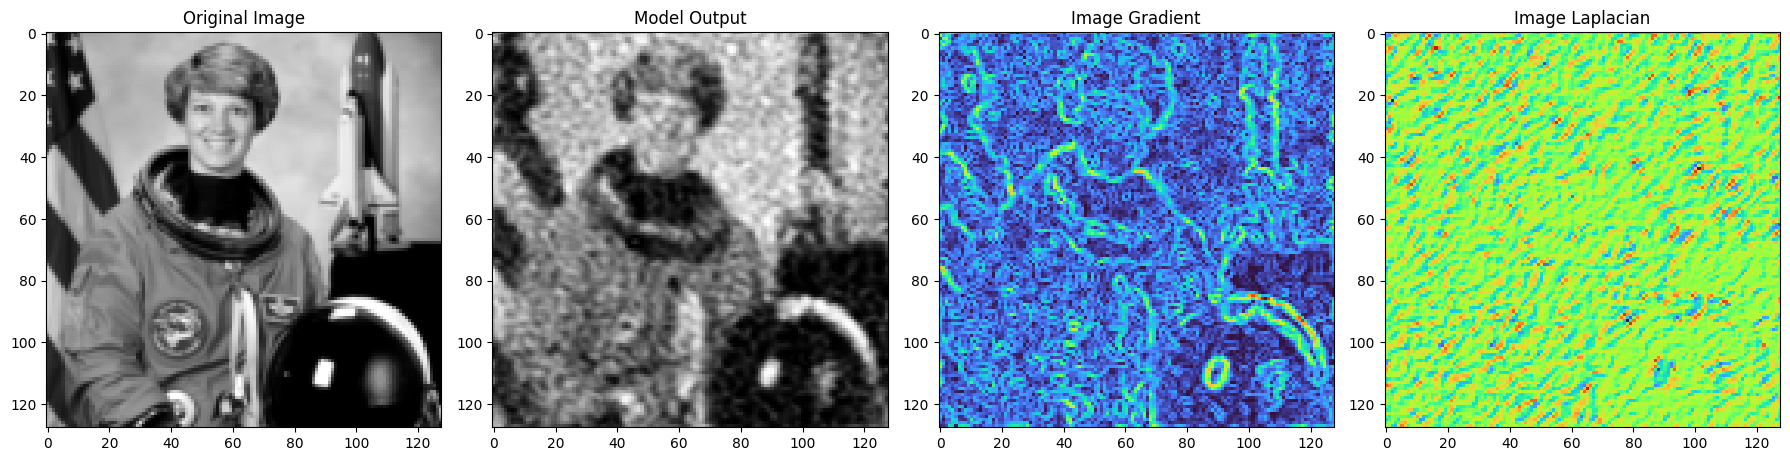

 94%|█████████▍| 472/500 [00:15<00:00, 32.62it/s]

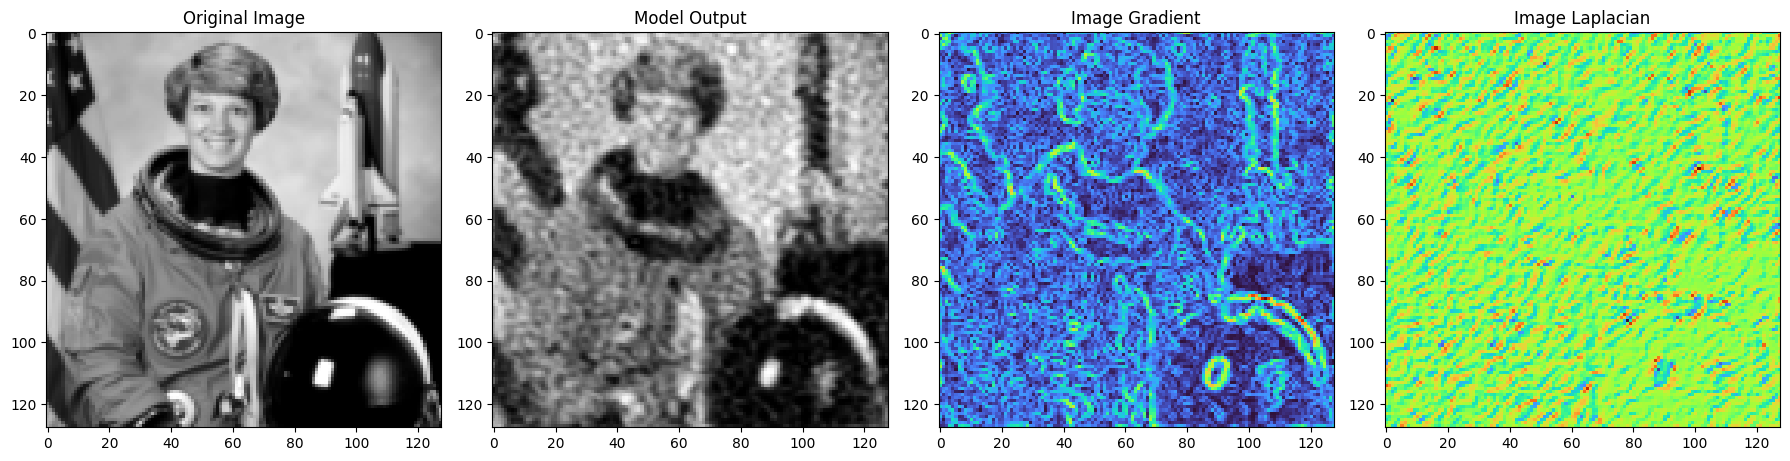

100%|██████████| 500/500 [00:16<00:00, 30.44it/s]


In [4]:
dataset = ImageDataset(height=128)

siren_loss, siren_psnr = train(
    model="SIREN",
    dataset=dataset,
    lr=1e-4,
    total_steps=500,
    steps_til_summary=25,
    device=device,
    **dict(
        in_features=2,
        out_features=1,
        hidden_features=128,
        hidden_layers=3,
    ),
)

Compare the loss and PSNR for the two models.

NameError: name 'mlp_loss' is not defined

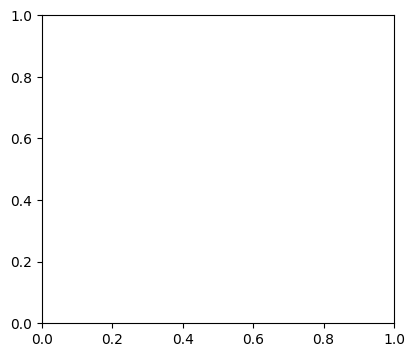

In [5]:
plt.figure(figsize=(10, 4))
plt.subplot(121)
plt.plot(mlp_loss, label="MLP")
plt.plot(siren_loss, label="SIREN")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.yscale("log")
plt.subplot(122)
plt.plot(mlp_psnr, label="MLP")
plt.plot(siren_psnr, label="SIREN")
plt.xlabel("Step")
plt.ylabel("PSNR")
plt.legend()
plt.show()